In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Práctica Cluster/agency_nodos_do.csv')
df


,SITE_ID,EXECUTION_ID,SHP_AGENCY_ID,SHP_AGEN_STATUS,Q_SHIPMENTS_DO,SHIPMENTS_DELAY,PICKUP_SUCCESS,PU,DO,DEVOS,DC,NEX,INSTALLATION_SVC,IS_SELLER,LOST,DAMAGED,STOLEN,BPP_CASHOUT_USD,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,HANDSHAKE_EMPTY,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE
0,MLB,MLB_2025-10-01_2025-12-31,13523,active,69546,1646.0,69494.0,True,True,True,False,False,False,False,28.0,0.0,0.0,1720.36,313.0,85.0,15.0,301.0,82.0,385.0,13.0,10.0,14.0
1,MLB,MLB_2025-10-01_2025-12-31,23708,active,78013,2856.0,77874.0,True,True,True,False,True,False,False,83.0,0.0,0.0,2027.37,261.0,20.0,7.0,255.0,19.0,265.0,16.0,0.0,1.0
2,MLB,MLB_2025-10-01_2025-12-31,451621,active,114746,4730.0,114637.0,True,True,True,False,False,False,False,34.0,0.0,0.0,2424.14,324.0,31.0,251.0,75.0,29.0,342.0,13.0,8.0,3.0
3,MLB,MLB_2025-10-01_2025-12-31,8861002,active,23067,1051.0,22939.0,True,True,True,False,False,False,False,17.0,0.0,0.0,344.70,118.0,36.0,15.0,107.0,32.0,149.0,5.0,4.0,2.0
4,MLB,MLB_2025-10-01_2025-12-31,24019,active,12659,721.0,12623.0,True,True,True,False,False,False,False,15.0,0.0,0.0,312.03,78.0,12.0,78.0,0.0,12.0,82.0,8.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,MLB,MLB_2025-10-01_2025-12-31,29279602,active,58227,2085.0,58174.0,True,True,True,False,False,False,False,13.0,0.0,0.0,2136.83,241.0,19.0,243.0,0.0,17.0,247.0,13.0,0.0,0.0
3589,MLB,MLB_2025-10-01_2025-12-31,84568483,active,13295,497.0,13268.0,True,True,True,False,True,False,False,13.0,0.0,0.0,89.40,62.0,11.0,62.0,0.0,11.0,67.0,6.0,0.0,5.0
3590,MLB,MLB_2025-10-01_2025-12-31,260180,active,17918,1640.0,17888.0,True,True,True,True,False,False,False,13.0,0.0,0.0,302.47,76.0,7.0,76.0,0.0,7.0,80.0,3.0,3.0,0.0
3591,MLB,MLB_2025-10-01_2025-12-31,240479194,active,42277,1377.0,42235.0,True,True,True,True,False,False,False,13.0,0.0,0.0,333.60,193.0,26.0,3.0,190.0,26.0,208.0,11.0,4.0,0.0


In [3]:
# en este dataset pueden haber places que no tengan volumen de shipments, esos no nos interesa
df['Q_SHIPMENTS_DO'].value_counts()[:3]

,count
Q_SHIPMENTS_DO,
0,73
8048,3
3604,3


In [4]:
places_sin_volumen = df[df['Q_SHIPMENTS_DO'] == 0]
df = df.drop(places_sin_volumen.index)

In [ ]:
df.shape

(3520, 27)

BPP es uno de los indicadores de performance mas importantes, deseo ver que tantos places hay con un bpp mayor a 0

In [5]:
df.loc[df['BPP_CASHOUT_USD']>0].shape

(1490, 27)

aproximadamente un 24% de los places tienen bpp

In [7]:
df.loc[df['BPP_CASHOUT_USD']>100].shape

(584, 27)

y un 7% con un bpp mayor a 100$

In [6]:
df.describe()

,Q_SHIPMENTS_DO,SHIPMENTS_DELAY,PICKUP_SUCCESS,LOST,DAMAGED,STOLEN,BPP_CASHOUT_USD,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,HANDSHAKE_EMPTY,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE
count,3520.000000,3520.00000,3518.000000,1965.000000,1965.0,1965.0,1490.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000
mean,17107.477841,739.72358,17092.559409,3.480407,0.0,0.0,203.642342,82.255966,11.156250,54.958523,27.806818,10.646875,70.677273,22.734943,1.787500,0.753977
std,23354.547113,864.42510,23335.684224,6.557924,0.0,0.0,474.347597,57.513507,14.385135,45.847449,52.575640,13.374405,72.111044,17.016947,2.510736,1.868126
min,1.000000,0.00000,1.000000,0.000000,0.0,0.0,2.180000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3719.250000,201.00000,3719.250000,0.000000,0.0,0.0,24.025000,60.000000,4.000000,31.000000,0.000000,4.000000,32.000000,8.000000,0.000000,0.000000
50%,9482.000000,480.50000,9472.500000,1.000000,0.0,0.0,62.890000,63.000000,8.000000,57.000000,3.000000,7.000000,56.000000,18.000000,1.000000,0.000000
75%,21901.000000,994.00000,21898.250000,4.000000,0.0,0.0,193.722500,79.000000,13.000000,63.000000,41.000000,13.000000,79.000000,35.000000,2.000000,1.000000
max,297518.000000,10727.00000,297236.000000,83.000000,0.0,0.0,10065.280000,1101.000000,227.000000,1136.000000,877.000000,215.000000,1148.000000,81.000000,33.000000,39.000000


In [8]:
#para kmeans las columnas sin varianza son inutiles e incluso contraproducentes
stds = df.std(numeric_only=True)
cols_sin_var = stds[stds == 0].index

In [9]:
df.drop(cols_sin_var, axis=1, inplace=True)

In [10]:
df.isna().sum()

,0
SITE_ID,0
EXECUTION_ID,0
SHP_AGENCY_ID,0
SHP_AGEN_STATUS,0
Q_SHIPMENTS_DO,0
SHIPMENTS_DELAY,0
PICKUP_SUCCESS,2
PU,0
DEVOS,0
DC,0


NaN= 0 eventos

In [11]:
#Imputacion y creacion de flags que se usaran para el modelo
df['BPP_CASHOUT_USD_isna'] = df['BPP_CASHOUT_USD'].isna().astype(int)
df['BPP_CASHOUT_USD'] = df['BPP_CASHOUT_USD'].fillna(0)


In [12]:
df['LOST_isna'] = df['LOST'].isna().astype(int)
df['LOST'] = df['LOST'].fillna(0)

In [13]:
df['BPP_CASHOUT_USD_isna'].value_counts() # 1 = era nan en la columna original

,count
BPP_CASHOUT_USD_isna,
1,2030
0,1490


In [14]:
df['LOST_isna'].value_counts() # 1 = era nan en la columna original

,count
LOST_isna,
0,1965
1,1555


In [15]:
#los pocos nan que quedan son, de igual manera, una señal de 0 eventos ocurridos en esa area, los nan daran problemas con PCA mas tarde, para evitarlos termino de imputar todo a 0
df.fillna(0, inplace=True)
df

,SITE_ID,EXECUTION_ID,SHP_AGENCY_ID,SHP_AGEN_STATUS,Q_SHIPMENTS_DO,SHIPMENTS_DELAY,PICKUP_SUCCESS,PU,DEVOS,DC,NEX,INSTALLATION_SVC,LOST,BPP_CASHOUT_USD,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,HANDSHAKE_EMPTY,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE,BPP_CASHOUT_USD_isna,LOST_isna
0,MLB,MLB_2025-10-01_2025-12-31,13523,active,69546,1646.0,69494.0,True,True,False,False,False,28.0,1720.36,313.0,85.0,15.0,301.0,82.0,385.0,13.0,10.0,14.0,0,0
1,MLB,MLB_2025-10-01_2025-12-31,23708,active,78013,2856.0,77874.0,True,True,False,True,False,83.0,2027.37,261.0,20.0,7.0,255.0,19.0,265.0,16.0,0.0,1.0,0,0
2,MLB,MLB_2025-10-01_2025-12-31,451621,active,114746,4730.0,114637.0,True,True,False,False,False,34.0,2424.14,324.0,31.0,251.0,75.0,29.0,342.0,13.0,8.0,3.0,0,0
3,MLB,MLB_2025-10-01_2025-12-31,8861002,active,23067,1051.0,22939.0,True,True,False,False,False,17.0,344.70,118.0,36.0,15.0,107.0,32.0,149.0,5.0,4.0,2.0,0,0
4,MLB,MLB_2025-10-01_2025-12-31,24019,active,12659,721.0,12623.0,True,True,False,False,False,15.0,312.03,78.0,12.0,78.0,0.0,12.0,82.0,8.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,MLB,MLB_2025-10-01_2025-12-31,29279602,active,58227,2085.0,58174.0,True,True,False,False,False,13.0,2136.83,241.0,19.0,243.0,0.0,17.0,247.0,13.0,0.0,0.0,0,0
3589,MLB,MLB_2025-10-01_2025-12-31,84568483,active,13295,497.0,13268.0,True,True,False,True,False,13.0,89.40,62.0,11.0,62.0,0.0,11.0,67.0,6.0,0.0,5.0,0,0
3590,MLB,MLB_2025-10-01_2025-12-31,260180,active,17918,1640.0,17888.0,True,True,True,False,False,13.0,302.47,76.0,7.0,76.0,0.0,7.0,80.0,3.0,3.0,0.0,0,0
3591,MLB,MLB_2025-10-01_2025-12-31,240479194,active,42277,1377.0,42235.0,True,True,True,False,False,13.0,333.60,193.0,26.0,3.0,190.0,26.0,208.0,11.0,4.0,0.0,0,0


Creacion de un df exclusivo para graficar variables y entender su distribucion, retiro las variables categoricas

In [16]:
df_plot = df.select_dtypes(include='number')

cols_to_drop = [c for c in df_plot.columns if df_plot[c].max() == 1]  # no quiero plotear variables categoricas

df_plot = df_plot.drop(columns=cols_to_drop)

In [17]:


num_cols = df_plot.select_dtypes(include='number').columns

for col in num_cols:
    data = df_plot[col].dropna()

    if data.nunique() <= 1:
        continue

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'Histograma + KDE - {col}', 'Boxplot'),
        column_widths=[0.3, 0.3]
    )

    #histograma
    fig.add_trace(
        go.Histogram(
            x=data,
            nbinsx=60,
            name='Hist',
            opacity=0.6,
            hovertemplate='Valor: %{x}<br>Conteo: %{y}<extra></extra>'
        ),
        row=1, col=1
    )

    #kde (la linea de distribucion)
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 500)

    #factor de escala: N * ancho del bin
    bin_width = (data.max() - data.min()) / 30
    kde_scaled = kde(x_vals) * len(data) * bin_width

    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=kde_scaled,
            mode='lines',
            name='KDE',
            hovertemplate='Valor: %{x}<br>Conteo estimado: %{y:.2f}<extra></extra>'
        ),
        row=1, col=1
    )

    # Boxplot
    fig.add_trace(
        go.Box(
            x=data,
            name=col,
            boxpoints='outliers',
            hovertemplate='Valor: %{x}<extra></extra>'
        ),
        row=1, col=2
    )

    #Limitar eje X por percentiles (solo visual)
    xmin, xmax = data.quantile([0.01, 0.99])
    fig.update_xaxes(range=[xmin, xmax], row=1, col=1)

    fig.update_layout(
        height=300,
        showlegend=False,
        margin=dict(t=40, l=30, r=30, b=30)
    )

    fig.show()


Se pueden identificar varias variables con una cola larga, es preciso que para que kmeans funcione de manera optima y estas variables no distorcionen los centroides y sesgue nuestro modelo lidiemos con estas variables, podemos usar tecnicas logaritmicas o de raiz cuadrada

cola muy larga de bpp, probablemente lo correcto seria poder categorizar la columna en terminos de presencia (0-1) en vez de terminos absolutos como lo es ahora, pero ya vemos que los places que tienen bpp son los que mas volumen tienen, seria justo castigar los places que mas volumen manejan por tener bpp? la estrategia pensada es dividir y hacer un ratio por volumen, a ver si funciona jijo

In [18]:
df_log = df.copy()

cols_long_tail = [
    'HANDSHAKE_DISAGREE',
    'HANDSHAKE_Y',
    'HANDSHAKE_N',
    'HANDSHAKE_AGREE',
    'Q_SHIPMENTS_DO',
    'SHIPMENTS_DELAY',
    'PICKUP_SUCCESS',
    'INCIDENT_WITH_DESC',
    'HANDSHAKE_EMPTY',
    'LOST',
    'BPP_CASHOUT_USD'

]

df_log[cols_long_tail] = np.log1p(df_log[cols_long_tail])


In [19]:
num_cols = df_log.select_dtypes(include='number').columns

for col in num_cols:
    data = df_log[col].dropna()

    if data.nunique() <= 1:
        continue

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'Histograma + KDE - {col}', 'Boxplot'),
        column_widths=[0.3, 0.3]
    )

    # Histograma en conteos reales
    fig.add_trace(
        go.Histogram(
            x=data,
            nbinsx=60,
            name='Hist',
            opacity=0.6,
            hovertemplate='Valor: %{x}<br>Conteo: %{y}<extra></extra>'
        ),
        row=1, col=1
    )

    # KDE reescalado a conteos
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 500)

    # factor de escala: N * ancho del bin
    bin_width = (data.max() - data.min()) / 30
    kde_scaled = kde(x_vals) * len(data) * bin_width

    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=kde_scaled,
            mode='lines',
            name='KDE',
            hovertemplate='Valor: %{x}<br>Conteo estimado: %{y:.2f}<extra></extra>'
        ),
        row=1, col=1
    )

    # Boxplot
    fig.add_trace(
        go.Box(
            x=data,
            name=col,
            boxpoints='outliers',
            hovertemplate='Valor: %{x}<extra></extra>'
        ),
        row=1, col=2
    )

    # Limitar eje X por percentiles (solo visual)
    xmin, xmax = data.quantile([0.01, 0.99])
    fig.update_xaxes(range=[xmin, xmax], row=1, col=1)

    fig.update_layout(
        height=300,
        showlegend=False,
        margin=dict(t=40, l=30, r=30, b=30)
    )

    fig.show()


Varias variables mejoraron, haciendo que kmeans pueda hacer un mejor trabajo, sin embargo algunas otras como bpp siguen con una cola muy larga, debido a esto creare un flag para esta columna y ese flag sera el que se usara para el modelo

In [20]:
df_log['LOST_flag'] = (df_log['LOST'] > 0).astype(int)


In [21]:
df_log['BPP_CASHOUT_USD_flag'] = (df_log['BPP_CASHOUT_USD'] > 0).astype(int)


In [22]:
df_log

,SITE_ID,EXECUTION_ID,SHP_AGENCY_ID,SHP_AGEN_STATUS,Q_SHIPMENTS_DO,SHIPMENTS_DELAY,PICKUP_SUCCESS,PU,DEVOS,DC,NEX,INSTALLATION_SVC,LOST,BPP_CASHOUT_USD,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,HANDSHAKE_EMPTY,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE,BPP_CASHOUT_USD_isna,LOST_isna,LOST_flag,BPP_CASHOUT_USD_flag
0,MLB,MLB_2025-10-01_2025-12-31,13523,active,11.149758,7.406711,11.149010,True,True,False,False,False,3.367296,7.450870,5.749393,4.454347,2.772589,5.710427,4.418841,5.955837,13.0,10.0,14.0,0,0,1,1
1,MLB,MLB_2025-10-01_2025-12-31,23708,active,11.264644,7.957527,11.262860,True,True,False,True,False,4.430817,7.614988,5.568345,3.044522,2.079442,5.545177,2.995732,5.583496,16.0,0.0,1.0,0,0,1,1
2,MLB,MLB_2025-10-01_2025-12-31,451621,active,11.650485,8.461892,11.649535,True,True,False,False,False,3.555348,7.793645,5.783825,3.465736,5.529429,4.330733,3.401197,5.837730,13.0,8.0,3.0,0,0,1,1
3,MLB,MLB_2025-10-01_2025-12-31,8861002,active,10.046202,6.958448,10.040637,True,True,False,False,False,2.890372,5.845571,4.779123,3.610918,2.772589,4.682131,3.496508,5.010635,5.0,4.0,2.0,0,0,1,1
4,MLB,MLB_2025-10-01_2025-12-31,24019,active,9.446203,6.582025,9.443355,True,True,False,False,False,2.772589,5.746299,4.369448,2.564949,4.369448,0.000000,2.564949,4.418841,8.0,1.0,0.0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,MLB,MLB_2025-10-01_2025-12-31,29279602,active,10.972122,7.643004,10.971211,True,True,False,False,False,2.639057,7.667547,5.488938,2.995732,5.497168,0.000000,2.890372,5.513429,13.0,0.0,0.0,0,0,1,1
3589,MLB,MLB_2025-10-01_2025-12-31,84568483,active,9.495219,6.210600,9.493186,True,True,False,True,False,2.639057,4.504244,4.143135,2.484907,4.143135,0.000000,2.484907,4.219508,6.0,0.0,5.0,0,0,1,1
3590,MLB,MLB_2025-10-01_2025-12-31,260180,active,9.793617,7.403061,9.791941,True,True,True,False,False,2.639057,5.715283,4.343805,2.079442,4.343805,0.000000,2.079442,4.394449,3.0,3.0,0.0,0,0,1,1
3591,MLB,MLB_2025-10-01_2025-12-31,240479194,active,10.652022,7.228388,10.651028,True,True,True,False,False,2.639057,5.812936,5.267858,3.295837,1.386294,5.252273,3.295837,5.342334,11.0,4.0,0.0,0,0,1,1


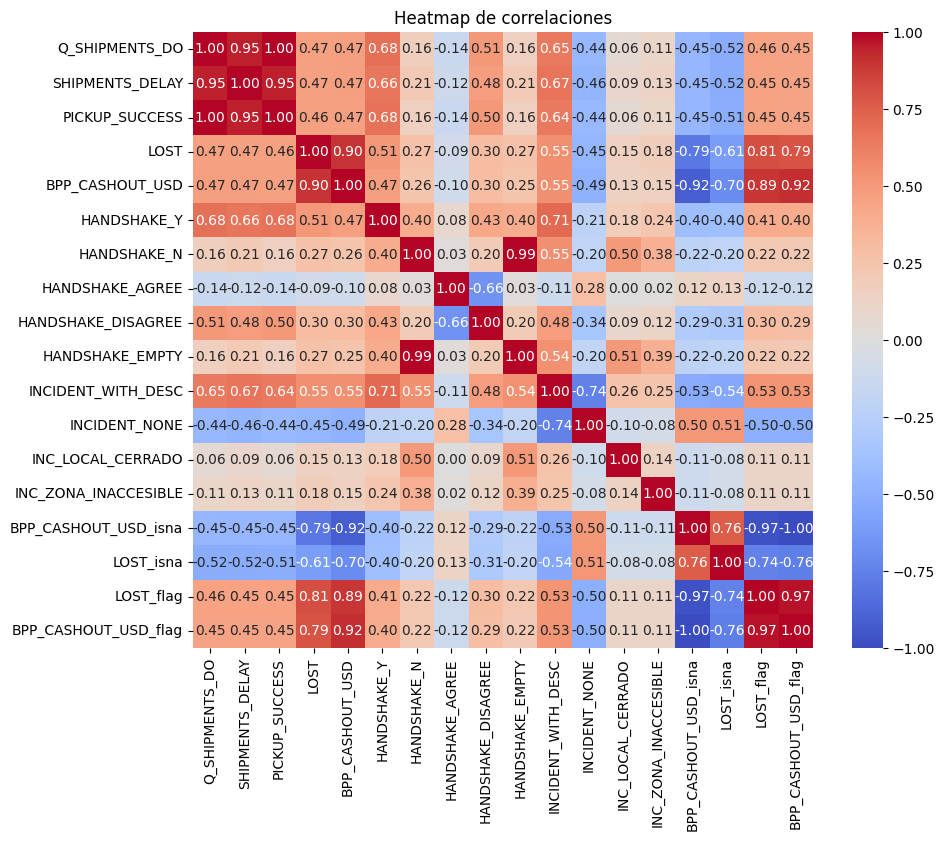

In [23]:
#Hora de ver las correlaciones en nuestro df
corr = df_log.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0           #0 como centro
)

plt.title("Heatmap de correlaciones")
plt.show()


In [132]:
#en base a esas relaciones voy a seleccionar las columnas mas oportunas (Tambien las que el negocio mas necesita que el modelo tome en cuenta)

df_model = df_log[
    [
        # métricas transformadas
        #'SHP_AGEN_CAPACITY',
        #'HANDSHAKE_Y',
        'INCIDENT_NONE',

       # 'PICKUP_SUCCESS',
        'HANDSHAKE_AGREE',
       # 'HANDSHAKE_DISAGREE',

        'Q_SHIPMENTS_DO',
      #  'BPP_CASHOUT_USD',

        'HANDSHAKE_EMPTY',

        # flags de presencia
       # 'BPP_CASHOUT_USD_flag',
       # 'LOST_flag',
       # 'INCIDENT_NONE',
      #  'INCIDENT_WITH_DESC',

        'INC_LOCAL_CERRADO'
    ]
]


In [159]:
corr = df_log[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [
    col for col in upper.columns
    if any(upper[col] > 0.85)
]

df_model = df_log.drop(columns=to_drop)
df_model = df_model.select_dtypes(include='number')


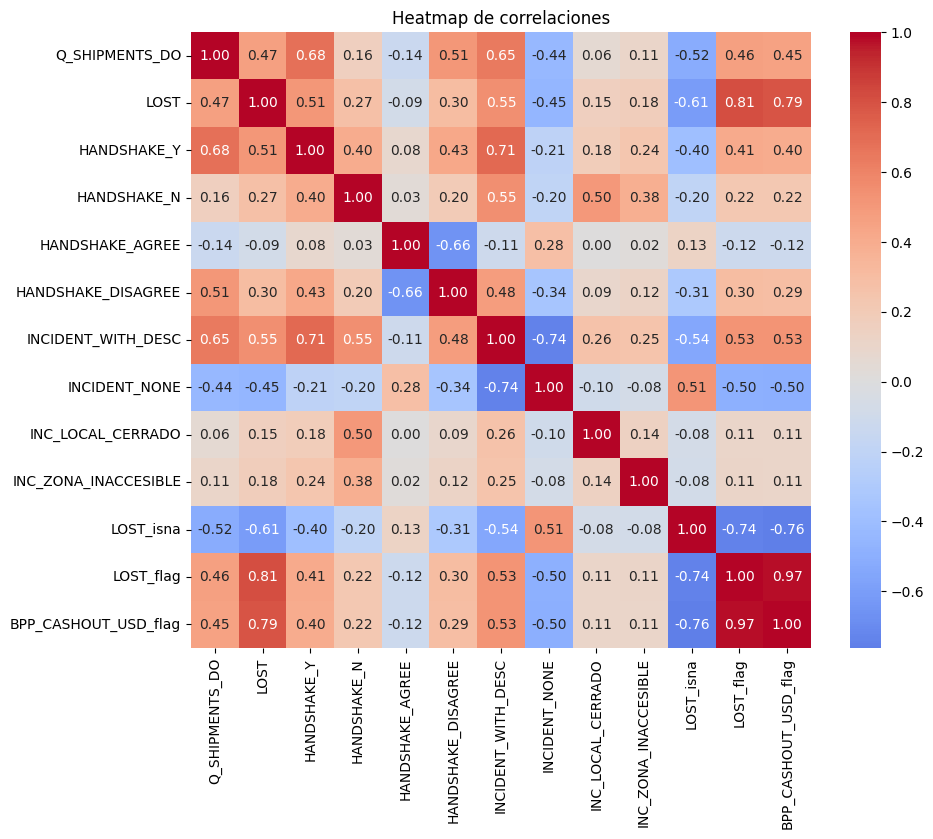

In [160]:
corr = df_model.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # muestra los valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",   # paleta divergente
    center=0           # 0 como centro (ideal para correlaciones)
)

plt.title("Heatmap de correlaciones")
plt.show()

In [185]:
df_model.drop(columns=['LOST_isna', 'LOST_flag'], axis=1, inplace=True)

In [209]:
df_model.describe()

,Q_SHIPMENTS_DO,LOST,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE,BPP_CASHOUT_USD_flag
count,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000
mean,8.960681,0.565751,4.306538,2.159354,3.745937,1.874785,3.936951,22.734943,1.787500,0.753977,0.423295
std,1.522488,0.831725,0.429596,0.790187,0.856617,1.837713,0.849392,17.016947,2.510736,1.868126,0.494152
min,0.693147,0.000000,1.609438,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.221546,0.000000,4.110874,1.609438,3.465736,0.000000,3.496508,8.000000,0.000000,0.000000,0.000000
50%,9.157256,0.000000,4.158883,2.197225,4.060443,1.386294,4.043051,18.000000,1.000000,0.000000,0.000000
75%,9.994333,1.098612,4.382027,2.639057,4.158883,3.737670,4.382027,35.000000,2.000000,1.000000,1.000000
max,12.603233,4.430817,7.004882,5.429346,7.036148,6.777647,7.046647,81.000000,33.000000,39.000000,1.000000


In [186]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)


In [187]:
#Hago pca para ver que queda mejor, con o sin pca, esta nota la hago luego de testear pca y el resultado sin me gusto mas, igual lo dejo acá, porque no?

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.40128886 0.15032538 0.11635392 0.08878784 0.07680594 0.06528095
 0.04065461]


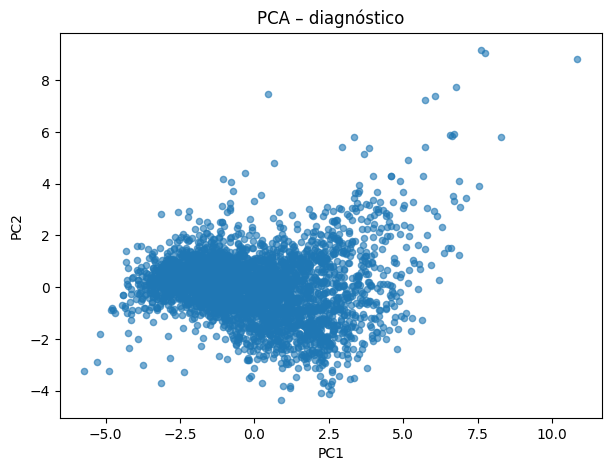

In [188]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=20, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA – diagnóstico')
plt.show()


In [199]:
from sklearn.cluster import KMeans

inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)


Text(0.5, 1.0, 'Elbow Method')

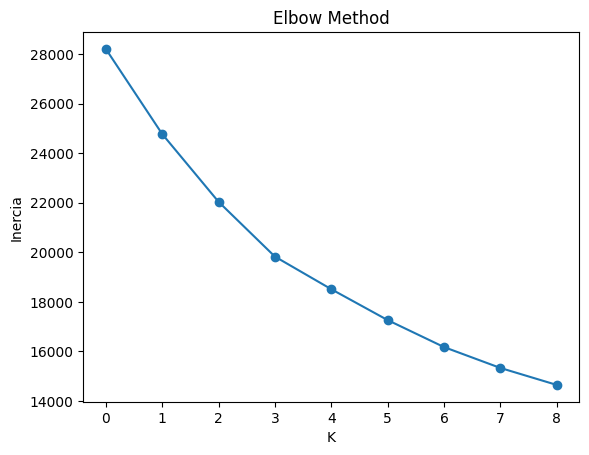

In [200]:
plt.plot(inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inercia')
plt.title('Elbow Method')

In [201]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    max_iter=1000
)

labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels


In [203]:
df['cluster'].value_counts()

,count
cluster,
0,1781
2,892
1,847


In [204]:
cluster_means = df.groupby('cluster')[[
    'Q_SHIPMENTS_DO',
    'BPP_CASHOUT_USD',
    'LOST',
    'HANDSHAKE_Y',
    'HANDSHAKE_N',
    'HANDSHAKE_EMPTY',
    'SHIPMENTS_DELAY',

]].mean()


In [210]:
df.describe()

,Q_SHIPMENTS_DO,SHIPMENTS_DELAY,PICKUP_SUCCESS,LOST,BPP_CASHOUT_USD,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_AGREE,HANDSHAKE_DISAGREE,HANDSHAKE_EMPTY,INCIDENT_WITH_DESC,INCIDENT_NONE,INC_LOCAL_CERRADO,INC_ZONA_INACCESIBLE,BPP_CASHOUT_USD_isna,LOST_isna,cluster
count,3520.000000,3520.00000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000,3520.000000
mean,17107.477841,739.72358,17082.847727,1.942898,86.200878,82.255966,11.156250,54.958523,27.806818,10.646875,70.677273,22.734943,1.787500,0.753977,0.576705,0.441761,0.747443
std,23354.547113,864.42510,23332.608402,5.195237,324.551113,57.513507,14.385135,45.847449,52.575640,13.374405,72.111044,17.016947,2.510736,1.868126,0.494152,0.496667,0.834139
min,1.000000,0.00000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3719.250000,201.00000,3712.500000,0.000000,0.000000,60.000000,4.000000,31.000000,0.000000,4.000000,32.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9482.000000,480.50000,9468.000000,0.000000,0.000000,63.000000,8.000000,57.000000,3.000000,7.000000,56.000000,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,21901.000000,994.00000,21886.750000,2.000000,45.565000,79.000000,13.000000,63.000000,41.000000,13.000000,79.000000,35.000000,2.000000,1.000000,1.000000,1.000000,2.000000
max,297518.000000,10727.00000,297236.000000,83.000000,10065.280000,1101.000000,227.000000,1136.000000,877.000000,215.000000,1148.000000,81.000000,33.000000,39.000000,1.000000,1.000000,2.000000


In [205]:
cluster_means

,Q_SHIPMENTS_DO,BPP_CASHOUT_USD,LOST,HANDSHAKE_Y,HANDSHAKE_N,HANDSHAKE_EMPTY,SHIPMENTS_DELAY
cluster,,,,,,,
0,5992.593487,4.139949,0.085907,60.203257,7.862998,7.582819,311.446378
1,30983.591499,224.130744,5.140496,119.311688,18.462810,17.390791,1287.794569
2,26123.779148,119.075224,2.614350,91.100897,10.793722,10.360987,1074.415919


## interpretacion segun los promedios

-cluster 1: places con un gran volumen, y un gran bpp tambien, hay un place en especifico asignado a este nodo que es un outlier extremo y distorsiona el promedio bastante, sin embargo otras features negativas como handshake_empty y lost son muy prominentes en este cluster tambien, estos son places con un gran volumen pero un performance que se podría mejorar, sobre todo en metricas como handshake empty

-cluster 2: places con un gran volumen tambien, aunque en promedio mas bajo al cluster 1, sin embargo con un performance mucho mas aceptable, menos delay, bpp, losts y handshake_empty que el cluster 1, estos places tienen un performance bueno tomando en cuenta su gran volumen

-cluster 0: cluster con mas places, bpp y lost casi nulos, se podria considerar que estos places son los lugares promedio y con un performance bastante bueno

## Visualicemos nuestros cluster para una mejor comprensión

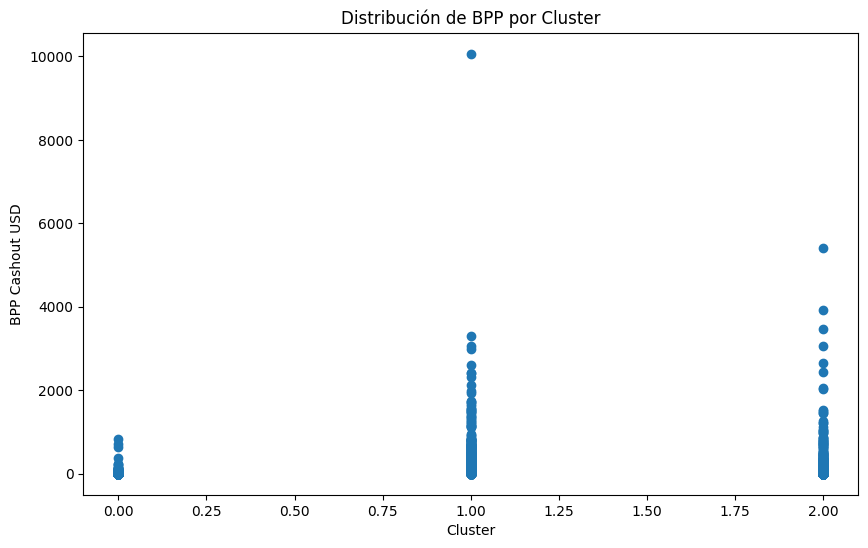

In [206]:
#Distribucion de bpp por cluster
plt.figure(figsize=(10, 6))
plt.scatter(df['cluster'], df['BPP_CASHOUT_USD'])
plt.xlabel('Cluster')
plt.ylabel('BPP Cashout USD')
plt.title('Distribución de BPP por Cluster')
plt.show()

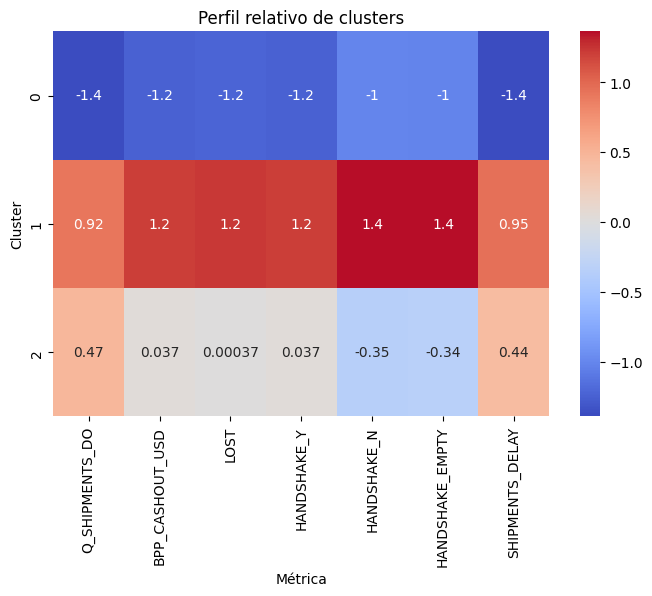

In [207]:
viz_data = cluster_means.copy()
viz_scaled = StandardScaler().fit_transform(viz_data)

viz_df = pd.DataFrame(
    viz_scaled,
    index=cluster_means.index,
    columns=cluster_means.columns
)
plt.figure(figsize=(8,5))
sns.heatmap(
    viz_df,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Perfil relativo de clusters')
plt.ylabel('Cluster')
plt.xlabel('Métrica')
plt.show()


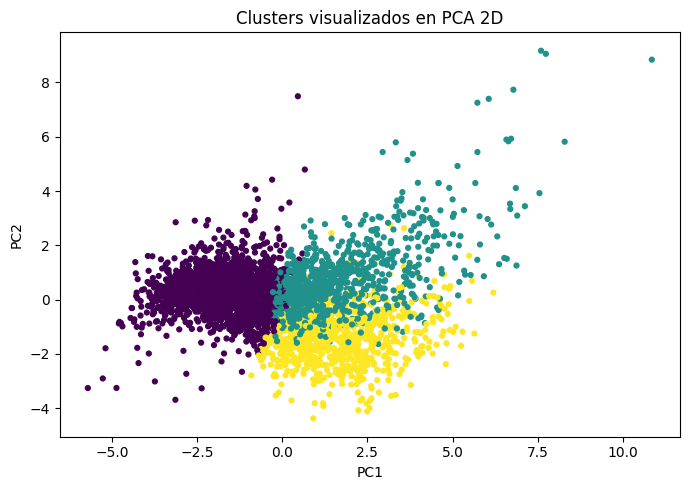

In [208]:
#Grafico muy util en caso de usar PCA

pca2 = PCA(n_components=0.9, random_state=42)

X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters visualizados en PCA 2D')
plt.tight_layout()
plt.show()